Grid size: 10x10 | NumPy time: 0.0698s | CuPy GPU time: 0.5457s
Grid size: 50x50 | NumPy time: 1.9317s | CuPy GPU time: 0.5648s
Grid size: 100x100 | NumPy time: 9.0504s | CuPy GPU time: 0.5737s
Grid size: 200x200 | NumPy time: 35.8726s | CuPy GPU time: 0.6848s
Grid size: 300x300 | NumPy time: 81.6092s | CuPy GPU time: 1.1192s


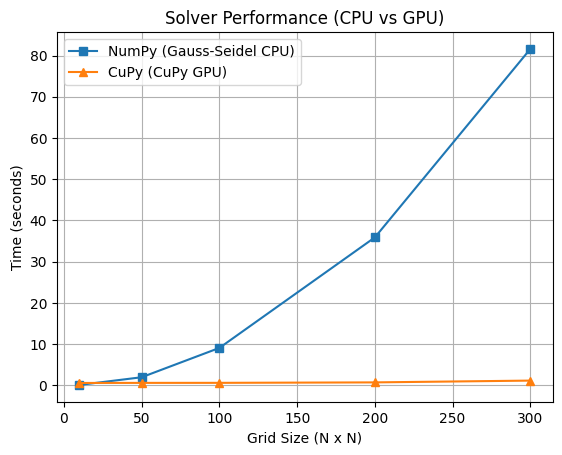

In [8]:

import numpy as np
import cupy as cp
import matplotlib.pyplot as plt
from timeit import default_timer as timer


def gauss_seidel(f):

    newf = f.copy()
    for i in range(1, newf.shape[0] - 1):
        for j in range(1, newf.shape[0] - 1):
            newf[i,j] = 0.25 * (newf[i,j+1] + newf[i, j-1]+
                                newf[i+1,j] + newf[i-1,j])

    return newf


def gauss_seidel_cupy(f):
    f = cp.array(f, dtype=cp.float64)
    newf = f.copy()


    newf[1:-1, 1:-1] = 0.25 * (
        cp.roll(f, shift=1, axis=0)[1:-1, 1:-1] +
        cp.roll(f, shift=-1, axis=0)[1:-1, 1:-1] +
        cp.roll(f, shift=1, axis=1)[1:-1, 1:-1] +
        cp.roll(f, shift=-1, axis=1)[1:-1, 1:-1]
    )
    return cp.asnumpy(newf)




def initialize(grid_sizes):
    times_numpy = []
    times_cupy = []

    for N in grid_sizes:
        f_numpy = np.random.rand(N, N).astype(np.float64)
        f_numpy[0, :] = f_numpy[-1, :] = f_numpy[:, 0] = f_numpy[:, -1] = 0
        f_cupy = cp.array(f_numpy.copy(), dtype=cp.float64)


        start_time = timer()
        for _ in range(1000):
            f_numpy = gauss_seidel(f_numpy)
        end_time = timer()
        times_numpy.append(end_time - start_time)


        start_time = timer()
        for _ in range(1000):
            f_cupy = gauss_seidel_cupy(f_cupy)
        end_time = timer()
        times_cupy.append(end_time - start_time)

        print(f"Grid size: {N}x{N} | NumPy time: {times_numpy[-1]:.4f}s | CuPy GPU time: {times_cupy[-1]:.4f}s")

    return times_numpy, times_cupy


if __name__ == "__main__":
    grid_sizes = [10, 50, 100, 200, 300]
    times_numpy, times_cupy = initialize(grid_sizes)


    plt.plot(grid_sizes, times_numpy, marker='s', linestyle='-', label='NumPy (Gauss-Seidel CPU)')
    plt.plot(grid_sizes, times_cupy, marker='^', linestyle='-', label='CuPy (CuPy GPU)')
    plt.xlabel('Grid Size (N x N)')
    plt.ylabel('Time (seconds)')
    plt.title('Solver Performance (CPU vs GPU)')
    plt.legend()
    plt.grid()
    plt.show()





